In [25]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt

In [ ]:
conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = ''
)

In [27]:
df = pd.read_sql_query("""
    
    SELECT *
    FROM (
    SELECT 
    CONCAT("Match-", CAST(ROW_NUMBER() OVER(ORDER BY ID) AS CHAR)) AS 'match_no',
    SUM(batsman_run) AS 'runs_scored',
    SUM(SUM(batsman_run)) OVER (ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS 'career_run',
    AVG(SUM(batsman_run)) OVER (ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS 'avg_run',
    AVG(SUM(batsman_run)) OVER (ROWS BETWEEN 10 PRECEDING AND CURRENT ROW) AS 'running_avg'
    FROM ipl.ipl
    WHERE batter = 'V Kohli'
    GROUP BY ID
    ) t;
    
    """, conn)

C:\Users\ACER\AppData\Local\Temp\ipykernel_7732\4063186594.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


In [28]:
df.head()

,match_no,runs_scored,career_run,avg_run,running_avg
0,Match-1,13.0,13.0,13.0000,13.0000
1,Match-2,12.0,25.0,12.5000,12.5000
2,Match-3,1.0,26.0,8.6667,8.6667
3,Match-4,9.0,35.0,8.7500,8.7500
4,Match-5,34.0,69.0,13.8000,13.8000


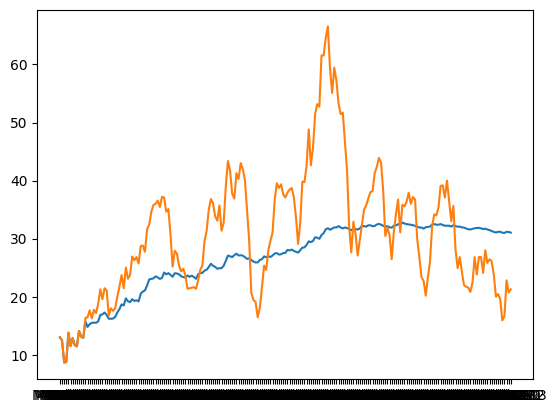

In [29]:
plt.plot(df['match_no'], df['avg_run'])
plt.plot(df['match_no'], df['running_avg'])